In [1]:
#common imports and variables

import pickle
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC Score",
    "Matthews Corr (MCC)"
]

def model_performance_analysis(y_test,y_pred,y_probs):
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)     
    auc = roc_auc_score(y_test, y_probs)    
    mcc=matthews_corrcoef(y_test, y_pred)
    
    score_matrix = [accuracy, precision, recall, f1, auc, mcc]
    df_scores = pd.DataFrame({"Score": score_matrix}, index=labels)
    print(df_scores.round(5))
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
# https://www.kaggle.com/datasets/uciml/mushroom-classification

# Preparing data 
df = pd.read_csv("train_data_mushrooms.csv")

# Data and label
X = df.drop('class', axis=1)
y = df['class']

# Encode
X = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y = le.fit_transform(y)

# Train/Test data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaled data for LR and kNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the fitted scaler to a file for later prediction
with open('./model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

                       Score
Accuracy             1.00000
Precision            1.00000
Recall               1.00000
F1-Score             1.00000
AUC Score            0.99914
Matthews Corr (MCC)  1.00000


/opt/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


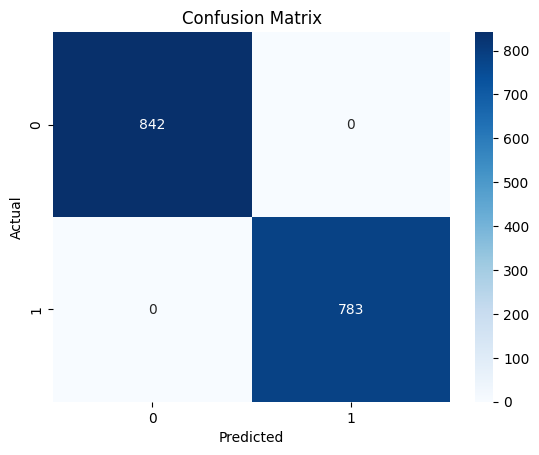

In [3]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=20)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

y_probs = lr.predict_proba(X_test)[:, 1]
model_performance_analysis(y_test, y_pred_lr,y_probs)

# Save the trained model as a pickle file
with open("./model/logistic_regression_model.pkl", "wb") as file:
    pickle.dump(lr, file)

                       Score
Accuracy             0.99877
Precision            1.00000
Recall               0.99745
F1-Score             0.99872
AUC Score            0.99914
Matthews Corr (MCC)  0.99754


/opt/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


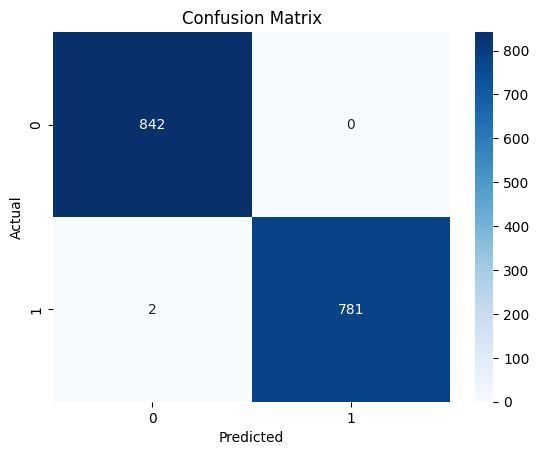

In [4]:
# kNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

y_probs = knn.predict_proba(X_test)[:, 1]
model_performance_analysis(y_test, y_pred_knn,y_probs)

# Save the trained model as a pickle file
with open("./model/knn_model.pkl", "wb") as file:
    pickle.dump(knn, file)


                       Score
Accuracy             1.00000
Precision            1.00000
Recall               1.00000
F1-Score             1.00000
AUC Score            0.99914
Matthews Corr (MCC)  1.00000


/opt/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


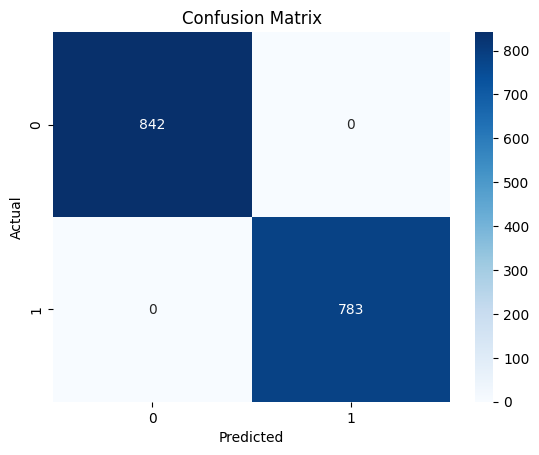

In [5]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, export_text

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

y_probs = dt.predict_proba(X_test)[:, 1]
model_performance_analysis(y_test, y_pred_dt,y_probs)

# Save the trained model as a pickle file
with open("./model/decision_tree_model.pkl", "wb") as file:
    pickle.dump(dt, file)



#tree_rules = export_text(dt,feature_names=list(X.columns))
#print(tree_rules)

                       Score
Accuracy             0.94892
Precision            0.90603
Recall               0.99745
F1-Score             0.94954
AUC Score            0.99914
Matthews Corr (MCC)  0.90233


/opt/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


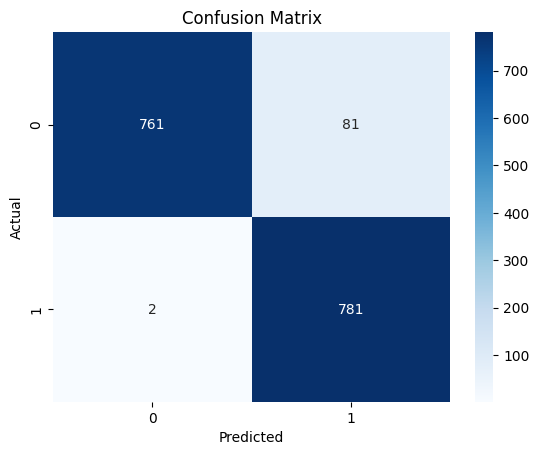

In [6]:
#Naive Bayes Classifier - Gaussian
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

y_probs = nb.predict_proba(X_test)[:, 1]
model_performance_analysis(y_test, y_pred_nb,y_probs)

# Save the trained model as a pickle file
with open("./model/naive_bayes_gaussian_model.pkl", "wb") as file:
    pickle.dump(nb, file)

/opt/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


                       Score
Accuracy             1.00000
Precision            1.00000
Recall               1.00000
F1-Score             1.00000
AUC Score            0.99914
Matthews Corr (MCC)  1.00000


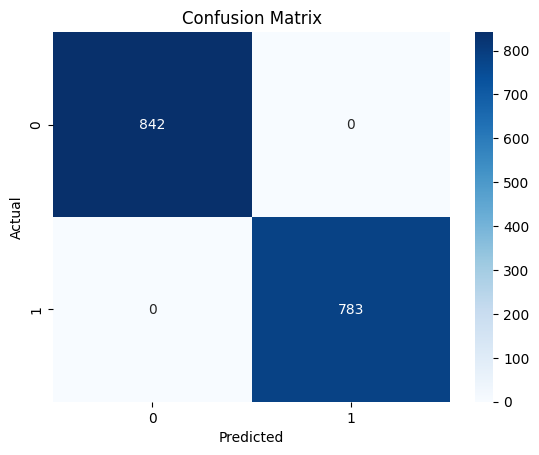

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

y_probs = rf.predict_proba(X_test)[:, 1]
model_performance_analysis(y_test, y_pred_rf,y_probs)

# Save the trained model as a pickle file
with open("./model/random_forest_model.pkl", "wb") as file:
    pickle.dump(rf, file)